## Step 1: Mount Google Drive

Connect Google Colab to Google Drive so we can access the customer dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Import the Libraries

Import the libraries needed to load the data, visualize the customers, scale the features, and create the K-Means model.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## Step 3: Load the Mall Customer Dataset

Load the Mall Customer Segmentation dataset from Google Drive.

In [ ]:
data = pd.read_csv(
    "/content/drive/MyDrive/Colab_Notebooks/AIRO_CLUB/Examples/Mall_Customers.csv"
)

## Step 4: Look at the Dataset

View the size of the dataset and the information available for each customer.

In [ ]:
print("Dataset Shape:", data.shape)

data.head()

Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Step 5: Check for Missing Values

Check whether any of the customer features contain missing data.

In [ ]:
data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Step 6: Select the Customer Features

Use Gender, Age, Annual Income, and Spending Score to group customers based on similar characteristics and purchasing behavior.

In [ ]:
X = data[[
    "Gender",
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


## Step 7: Prepare the Features

Convert Gender into a numerical feature and scale the numerical features so they can be compared fairly by K-Means.

In [ ]:
numeric_features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

categorical_features = [
    "Gender"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="if_binary",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

X_prepared = preprocessor.fit_transform(X)

## Step 8: Select Two Features for the First K-Means Example

Start with Annual Income and Spending Score so we can directly visualize how K-Means groups customers in two dimensions.

In [ ]:
X_2d = data[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

X_2d.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Step 9: Scale the Two Features

Standardize Annual Income and Spending Score so both features contribute fairly to the distance calculations used by K-Means.

In [ ]:
scaler_2d = StandardScaler()

X_2d_scaled = scaler_2d.fit_transform(
    X_2d
)

## Step 10: Visualize the Customers Before Clustering

Plot Annual Income and Spending Score before K-Means assigns customers to clusters.

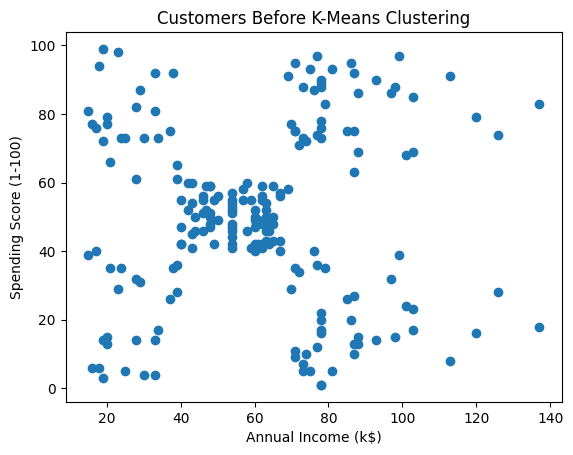

In [ ]:
plt.scatter(
    X_2d["Annual Income (k$)"],
    X_2d["Spending Score (1-100)"]
)

plt.title("Customers Before K-Means Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()

## Step 11: Test Different Values of K

Run K-Means with different numbers of clusters and record the inertia for each value of K.

In [ ]:
inertias_2d = []

k_values = range(1, 11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    model.fit(X_2d_scaled)

    inertias_2d.append(
        model.inertia_
    )

## Step 12: Plot the Elbow Method

Plot the inertia for each value of K to help choose a reasonable number of customer clusters.

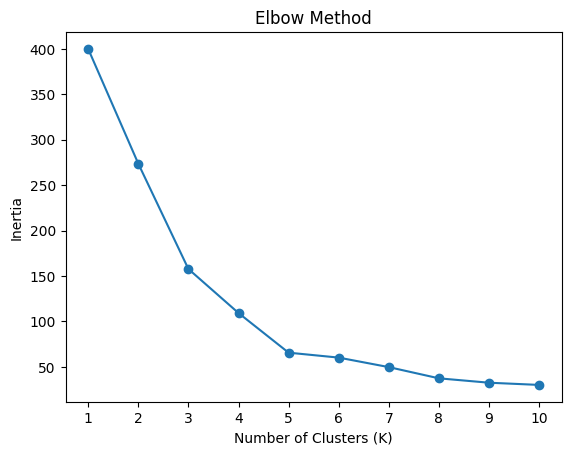

In [ ]:
plt.plot(
    k_values,
    inertias_2d,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)

plt.show()

## Step 13: Calculate the Silhouette Scores

Test different numbers of clusters and calculate a silhouette score for each one.

Higher silhouette scores indicate clusters that are more compact and better separated from one another.

In [ ]:
silhouette_scores_2d = []

k_values_silhouette = range(2, 11)

for k in k_values_silhouette:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    cluster_labels = model.fit_predict(
        X_2d_scaled
    )

    score = silhouette_score(
        X_2d_scaled,
        cluster_labels
    )

    silhouette_scores_2d.append(score)

## Step 14: Find the Best Number of Clusters

Compare the silhouette score for each value of K and automatically select the value with the highest score.

In [ ]:
silhouette_results_2d = pd.DataFrame({
    "K": list(k_values_silhouette),
    "Silhouette Score": silhouette_scores_2d
})

silhouette_results_2d["Silhouette Score"] = (
    silhouette_results_2d["Silhouette Score"].round(3)
)

print(
    silhouette_results_2d.to_string(
        index=False
    )
)

best_k_2d = silhouette_results_2d.loc[
    silhouette_results_2d["Silhouette Score"].idxmax(),
    "K"
]

print()
print("Best Number of Clusters:", best_k_2d)

 K  Silhouette Score
 2             0.397
 3             0.467
 4             0.494
 5             0.555
 6             0.514
 7             0.502
 8             0.455
 9             0.457
10             0.445

Best Number of Clusters: 5


## Step 15: Fit the Model and Assign Customers to Clusters

Run K-Means using Annual Income and Spending Score and assign each customer to a cluster.

In [ ]:
model_2d = KMeans(
    n_clusters=best_k_2d,
    random_state=42,
    n_init="auto"
)

clusters_2d = model_2d.fit_predict(
    X_2d_scaled
)

## Step 16: Find the Cluster Centers

Convert the K-Means cluster centers back into the original Annual Income and Spending Score units.

In [ ]:
centers_2d = scaler_2d.inverse_transform(
    model_2d.cluster_centers_
)

centers_2d

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

## Step 17: Visualize the Two-Feature Customer Segments

Plot the customer clusters and their cluster centers using Annual Income and Spending Score.

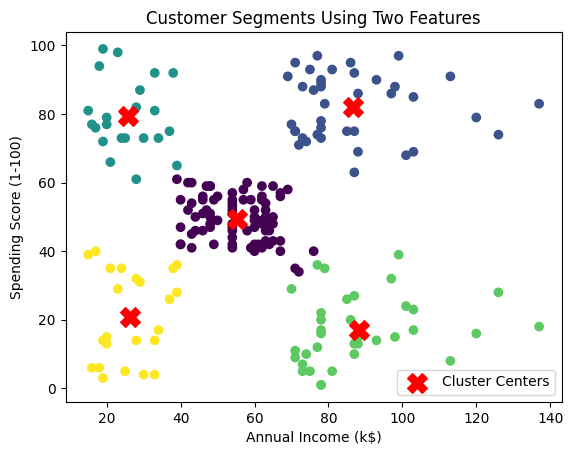

In [ ]:
plt.scatter(
    X_2d["Annual Income (k$)"],
    X_2d["Spending Score (1-100)"],
    c=clusters_2d,
    cmap="viridis"
)

plt.scatter(
    centers_2d[:, 0],
    centers_2d[:, 1],
    marker="X",
    s=200,
    c="red",
    label="Cluster Centers"
)

plt.title("Customer Segments Using Two Features")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

# K-Means Using All Customer Features

Now we will repeat the clustering using Gender, Age, Annual Income, and Spending Score.

Because these features create a higher-dimensional dataset, PCA will be used afterward to create a two-dimensional visualization.

## Step 18: Test Different Values of K Using All Features

Run K-Means using Gender, Age, Annual Income, and Spending Score and record the inertia for each value of K.

In [ ]:
inertias_all = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    model.fit(X_prepared)

    inertias_all.append(
        model.inertia_
    )

## Step 19: Plot the Elbow Method Using All Features

Plot the inertia values to determine a reasonable number of clusters when all customer features are used.

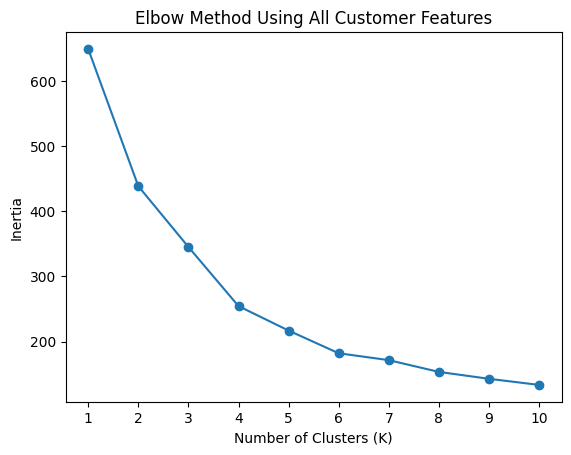

In [ ]:
plt.plot(
    k_values,
    inertias_all,
    marker="o"
)

plt.title("Elbow Method Using All Customer Features")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)

plt.show()

## Step 20: Calculate Silhouette Scores Using All Features

In [ ]:
silhouette_scores_all = []

k_values_silhouette = range(2, 11)

for k in k_values_silhouette:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    cluster_labels = model.fit_predict(
        X_prepared
    )

    score = silhouette_score(
        X_prepared,
        cluster_labels
    )

    silhouette_scores_all.append(score)

## Step 21: Find the Best Number of Clusters Using All Features

In [ ]:
silhouette_results_all = pd.DataFrame({
    "K": list(k_values_silhouette),
    "Silhouette Score": silhouette_scores_all
})

silhouette_results_all["Silhouette Score"] = (
    silhouette_results_all["Silhouette Score"].round(3)
)

print(
    silhouette_results_all.to_string(
        index=False
    )
)

best_k_all = silhouette_results_all.loc[
    silhouette_results_all["Silhouette Score"].idxmax(),
    "K"
]

print()
print("Best Number of Clusters:", best_k_all)

 K  Silhouette Score
 2             0.303
 3             0.312
 4             0.350
 5             0.350
 6             0.356
 7             0.332
 8             0.336
 9             0.312
10             0.309

Best Number of Clusters: 6


## Step 22: Create the All-Feature K-Means Model

Create a K-Means model using the number of clusters selected from the all-feature elbow plot and Silhouette Score.

In [ ]:
model_all = KMeans(
    n_clusters=best_k_all,
    random_state=42,
    n_init="auto"
)

## Step 23: Fit the All-Feature Model

Run K-Means using Gender, Age, Annual Income, and Spending Score.

In [ ]:
clusters_all = model_all.fit_predict(
    X_prepared
)

clusters_all

array([4, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4,
       2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0, 4, 2, 5,
       2, 4, 0, 5, 5, 5, 0, 5, 5, 0, 0, 0, 0, 0, 5, 0, 0, 5, 0, 0, 0, 5,
       0, 0, 5, 5, 0, 0, 0, 0, 0, 5, 0, 5, 5, 0, 0, 5, 0, 0, 5, 0, 0, 5,
       5, 0, 0, 5, 0, 5, 5, 5, 0, 5, 0, 5, 5, 0, 0, 5, 0, 5, 0, 0, 0, 0,
       0, 5, 5, 5, 5, 5, 0, 0, 0, 0, 5, 5, 5, 1, 5, 1, 3, 1, 3, 1, 3, 1,
       5, 1, 3, 1, 3, 1, 3, 1, 3, 1, 5, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

## Step 24: Add the All-Feature Cluster Assignments

Add each customer's K-Means cluster assignment to the original dataset.

In [ ]:
data["Cluster"] = clusters_all

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,2
3,4,Female,23,16,77,4
4,5,Female,31,17,40,2


## Step 25: Reduce the Features to Two Dimensions with PCA

Use Principal Component Analysis (PCA) to compress the prepared customer features into two dimensions that can be visualized.

PCA is only being used for visualization. K-Means was trained using all of the prepared features.

In [ ]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_prepared
)

## Step 26: Check How Much Variation PCA Preserved

Calculate how much of the variation in the original customer features is represented by the two PCA dimensions.

In [ ]:
variation_preserved = (
    pca.explained_variance_ratio_.sum() * 100
)

print(
    "Variation Preserved:",
    round(variation_preserved, 2),
    "%"
)

Variation Preserved: 71.77 %


## Step 27: Visualize the All-Feature Clusters with PCA

Plot the customer segments in two dimensions after clustering with Gender, Age, Annual Income, and Spending Score.

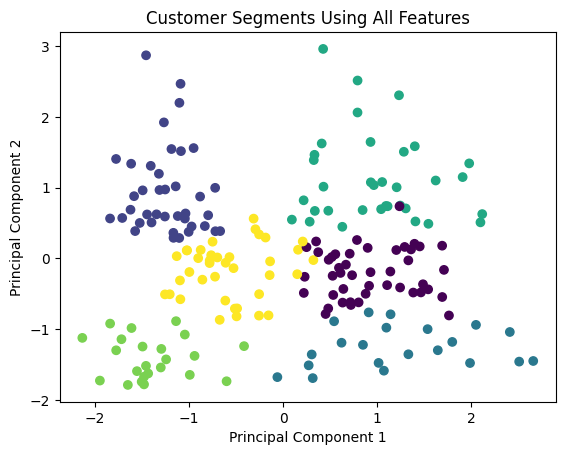

In [ ]:
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_all,
    cmap="viridis"
)

plt.title("Customer Segments Using All Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

## Step 28: Count the Customers in Each Cluster

See how many customers were assigned to each all-feature customer segment.

In [ ]:
data["Cluster"].value_counts().sort_index()

,count
Cluster,
0,45
1,39
2,21
3,34
4,23
5,38


## Step 29: Summarize Each Customer Segment

Calculate the average Age, Annual Income, and Spending Score for each cluster.

In [ ]:
cluster_summary = data.groupby("Cluster").agg(
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean"),
    Customers=("CustomerID", "count")
)

cluster_summary.round(2)

,Average_Age,Average_Income,Average_Spending,Customers
Cluster,,,,
0,56.33,54.27,49.07,45
1,32.69,86.54,82.13,39
2,45.52,26.29,19.38,21
3,41.26,88.50,16.76,34
4,25.00,25.26,77.61,23
5,27.00,56.66,49.13,38


## Step 30: Interpret the Customer Segments

K-Means discovered groups of customers with similar characteristics.

The final model used:

- Gender
- Age
- Annual Income
- Spending Score

The cluster numbers do not have predefined meanings. After K-Means creates the clusters, we examine the characteristics of each group to determine what each customer segment may represent.

Businesses could use these customer segments to better understand their customers and develop different marketing strategies for different groups.